In [1]:
pip uninstall -y scikit-learn numpy scipy

Found existing installation: scikit-learn 1.2.2
Uninstalling scikit-learn-1.2.2:
  Successfully uninstalled scikit-learn-1.2.2
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.15.3
Uninstalling scipy-1.15.3:
  Successfully uninstalled scipy-1.15.3
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install numpy==1.26.4 scipy==1.11.4 scikit-learn==1.4.2 imbalanced-learn==0.14.0 --no-cache-dir --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 289.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 291.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 279.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 285.2 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 354.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 385.2 MB/s eta 0:00:00
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.6.0
    Uninstalling threadpoolctl-3.6.0:
      Successfully uninstalled threadpoolctl-3.6.0
  Attempting uninstall: joblib
    Found existing installation: joblib 1.5.1
    Uninstalling joblib-1.5.1:
      Successfully uninstalled joblib-1.5.1
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbal

In [3]:
import os
import tensorflow as tf

# Enable dynamic GPU memory allocation
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU found and configured for dynamic memory allocation.")
    except Exception as e:
        print(f"Error configuring GPU, defaulting to CPU. Error: {e}")
        os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
else:
    print("No GPU found. Using CPU.")
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

2026-01-11 07:15:28.090505: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768115728.278756      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768115728.335550      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


GPU found and configured for dynamic memory allocation.


In [4]:
import os
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input, Bidirectional, LSTM, GRU, Reshape, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from imblearn.keras import BalancedBatchGenerator

In [5]:
# --- Section 1: Data Loading and Preprocessing ---
import os
import scipy.io
import numpy as np
import gc

base_path = '/kaggle/input/bciaut-p300/data'
all_eeg_data = []
all_eeg_labels = []
all_subject_ids = []
subjects = sorted([d for d in os.listdir(base_path) if d.startswith('SBJ')])
print(f"Found {len(subjects)} subjects. Starting data loading...")

for subject_id in subjects:
    subject_path = os.path.join(base_path, subject_id)
    sessions = sorted([d for d in os.listdir(subject_path) if d.startswith('S')])
    for session_id in sessions:
        train_data_path = os.path.join(subject_path, session_id, 'Train', 'trainData.mat')
        train_labels_path = os.path.join(subject_path, session_id, 'Train', 'trainTargets.txt')
        try:
            eeg_data_dict = scipy.io.loadmat(train_data_path)
            eeg_data = eeg_data_dict['trainData']
            if eeg_data.size == 0:
                print(f"Empty data in {train_data_path}, skipping.")
                continue
            eeg_labels = np.loadtxt(train_labels_path)
            all_eeg_data.append(eeg_data)
            all_eeg_labels.append(eeg_labels)
            subject_numeric_id = int(subject_id.replace("SBJ", ""))
            all_subject_ids.append(
            np.full(len(eeg_labels), subject_numeric_id)
            )
            del eeg_data, eeg_data_dict  # Free memory
            gc.collect()
        except Exception as e:
            print(f"Error loading {session_id}: {e}")
            continue

if all_eeg_data:
    combined_eeg_data = np.concatenate(all_eeg_data, axis=2)
    combined_eeg_labels = np.concatenate(all_eeg_labels)
    combined_subject_ids = np.concatenate(all_subject_ids)
    print("\nData loading complete!")
    print("Shape of combined EEG data:", combined_eeg_data.shape)
    print("Shape of combined labels:", combined_eeg_labels.shape)
    print("Shape of combined subject ids:", combined_subject_ids.shape)
else:
    print("\nNo data was loaded. Please check the file path.")
    raise ValueError("No data loaded, stopping execution.")

Found 15 subjects. Starting data loading...

Data loading complete!
Shape of combined EEG data: (8, 350, 168000)
Shape of combined labels: (168000,)
Shape of combined subject ids: (168000,)


In [6]:
X = np.transpose(combined_eeg_data, (2, 1, 0))
y = combined_eeg_labels.astype(int)
subject_ids = combined_subject_ids

In [7]:
import numpy as np
import scipy.signal as sg
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE
import gc

In [8]:
SFREQ = 250                     # Hz
WINDOW_START = -200             # in ms (dataset reference only)
CROP_START_MS = 200             # desired window start (200ms)
CROP_END_MS   = 600             # desired window end (600ms)

LOWCUT = 0.1
HIGHCUT = 30.0

In [9]:
# dataset samples: -200 ms → 1200 ms = 1400ms total
# 1 ms = SFREQ / 1000 samples

samples_per_ms = SFREQ / 1000
crop_start_idx = int((CROP_START_MS - WINDOW_START) * samples_per_ms)
crop_end_idx   = int((CROP_END_MS   - WINDOW_START) * samples_per_ms)

print("Cropping indices:", crop_start_idx, crop_end_idx)

Cropping indices: 100 200


In [10]:
def bandpass_filter(X, sfreq=SFREQ, low=LOWCUT, high=HIGHCUT):
    ny = 0.5 * sfreq
    b, a = sg.butter(4, [low/ny, high/ny], btype='band')
    
    Xf = np.zeros_like(X)

    for i in range(X.shape[0]):         # samples
        for ch in range(X.shape[2]):    # channels
            Xf[i,:,ch] = sg.filtfilt(b, a, X[i,:,ch])

    return Xf

In [11]:
def apply_feature_engineering(X):
    print(" → Bandpass 0.1–30 Hz")
    X = bandpass_filter(X)
    return X

In [12]:
X = np.transpose(combined_eeg_data, (2, 1, 0))
y = combined_eeg_labels.astype(int)

print("Raw X:", X.shape)

X = X[:, crop_start_idx : crop_end_idx, :]
print("After cropping:", X.shape)

mean = X.mean(axis=(0,1), keepdims=True)
std  = X.std(axis=(0,1), keepdims=True)
X = (X - mean) / std


Raw X: (168000, 350, 8)
After cropping: (168000, 100, 8)


In [13]:
import numpy as np

# y is already 1D (0 = non-P300, 1 = P300)
y_labels = y.astype(int)

# Indices
p300_idx = np.where(y_labels == 1)[0]
non_p300_idx = np.where(y_labels == 0)[0]

print("Before balancing:")
print("P300:", len(p300_idx))
print("Non-P300:", len(non_p300_idx))

# Downsample non-P300
np.random.seed(42)
non_p300_downsampled = np.random.choice(
    non_p300_idx,
    size=len(p300_idx),
    replace=False
)

# Combine
balanced_idx = np.concatenate([p300_idx, non_p300_downsampled])
np.random.shuffle(balanced_idx)

X_balanced = X[balanced_idx]
y_balanced = y_labels[balanced_idx]

print("After balancing:")
print("Class counts:", np.bincount(y_balanced))

Before balancing:
P300: 21000
Non-P300: 147000
After balancing:
Class counts: [21000 21000]


In [14]:
from tensorflow.keras.utils import to_categorical

y_balanced_cat = to_categorical(y_balanced, num_classes=2)

In [15]:
from sklearn.model_selection import train_test_split

# Train vs temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.30,
    stratify=y_balanced,
    random_state=42
)

# Val vs Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [16]:
def subject_wise_zscore(X):
    # X shape: (trials, time, channels)
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True) + 1e-6
    return (X - mean) / std

X_train = subject_wise_zscore(X_train)
X_val = subject_wise_zscore(X_val)
X_test  = subject_wise_zscore(X_test)

In [17]:
print("\nApplying feature engineering...")
X_train_fe = apply_feature_engineering(X_train)


Applying feature engineering...
 → Bandpass 0.1–30 Hz


In [18]:
X_train_final = X_train_fe[..., np.newaxis]
X_val_final   = X_val[..., np.newaxis]
X_test_final  = X_test[..., np.newaxis]

y_train_cat = to_categorical(y_train)
y_val_cat   = to_categorical(y_val)
y_test_cat  = to_categorical(y_test)

In [19]:
print("Final train:", X_train_final.shape)
print("Final val:",   X_val_final.shape)
print("Final test:",  X_test_final.shape)

Final train: (29400, 100, 8, 1)
Final val: (6300, 100, 8, 1)
Final test: (6300, 100, 8, 1)


In [20]:
num_classes = y_train_cat.shape[1]

In [21]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight = {
    0: class_weights[0],
    1: class_weights[1]
}

print("Class weights:", class_weight)

Class weights: {0: 1.0, 1: 1.0}


In [22]:
def plot_training_history(history, model_name):
    """Plots all available metrics in the training history."""
    available_metrics = list(history.history.keys())
    print(f"Available metrics in history: {available_metrics}")

    plt.figure(figsize=(12, 5))
    # Plot loss
    if 'loss' in available_metrics:
        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='Training Loss')
        if 'val_loss' in available_metrics:
            plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title(f'{model_name} Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
    
    # Plot other metrics
    plt.subplot(1, 2, 2)
    metric_plotted = False
    for metric in available_metrics:
        if metric not in ['loss', 'val_loss']:
            plt.plot(history.history[metric], label=f'Training {metric.capitalize()}')
            val_metric = 'val_' + metric
            if val_metric in available_metrics:
                plt.plot(history.history[val_metric], label=f'Validation {metric.capitalize()}')
            metric_plotted = True

    if metric_plotted:
        plt.title(f'{model_name} Metrics')
        plt.xlabel('Epochs')
        plt.ylabel('Metric Value')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()



# --- Function to plot confusion matrix ---
def plot_confusion_matrix(y_true, y_pred, model_name, labels=['Non-P300', 'P300'], title_suffix=''):
    """
    Generates and displays a confusion matrix plot.
    
    y_true: true labels
    y_pred: predicted labels (can be probabilities or class indices)
    """
    # If y_pred are probabilities, convert to class indices
    if y_pred.ndim > 1 and y_pred.shape[1] > 1:
        y_pred = y_pred.argmax(axis=1)
    
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(f'Confusion Matrix for {model_name}{title_suffix}')
    plt.show()


In [23]:
# --- Function to adjust threshold and evaluate ---
def adjust_threshold_and_evaluate(y_true_int, y_pred_probs, model_name, threshold):
    """
    Adjusts the classification threshold and prints new performance metrics.
    """
    print(f"\n--- Evaluating {model_name} with Threshold: {threshold} ---")
    y_pred_adjusted = (y_pred_probs[:, 1] > threshold).astype(int)
    
    report = classification_report(y_true_int, y_pred_adjusted, target_names=['Non-P300', 'P300'], output_dict=True)
    print(classification_report(y_true_int, y_pred_adjusted, target_names=['Non-P300', 'P300']))
    
    plot_confusion_matrix(y_true_int, y_pred_adjusted, model_name, title_suffix=f' (Threshold: {threshold})')
    
    return report

In [24]:
input_shape = (X_train_final.shape[1:])
print(f"The input_shape is: {input_shape}")

The input_shape is: (100, 8, 1)


In [25]:
input_shape_2d = X_train_final.shape[0:]
print(f"The input_shape_2d for the 2D CNN is: {input_shape_2d}")

The input_shape_2d for the 2D CNN is: (29400, 100, 8, 1)


In [26]:
from sklearn.metrics import f1_score

In [27]:
class P300MacroF1Checkpoint(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val, filepath, threshold=0.3):
        super().__init__()
        self.X_val = X_val
        self.y_val = np.argmax(y_val, axis=1)
        self.filepath = filepath
        self.threshold = threshold
        self.best_f1 = 0.0

    def on_epoch_end(self, epoch, logs=None):
        probs = self.model.predict(self.X_val, verbose=0)[:, 1]
        y_pred = (probs >= self.threshold).astype(int)

        f1_p300 = f1_score(self.y_val, y_pred, pos_label=1, zero_division=0)
        f1_nonp300 = f1_score(self.y_val, y_pred, pos_label=0, zero_division=0)

        f1_macro = 0.5 * (f1_p300 + f1_nonp300)

        if f1_macro > self.best_f1:
            self.best_f1 = f1_macro
            self.model.save(self.filepath, include_optimizer=False)
            print(
                f"  Saved best model — "
                f"F1_macro: {f1_macro:.4f} | "
                f"F1_P300: {f1_p300:.4f} | "
                f"F1_NonP300: {f1_nonp300:.4f}"
            )

In [28]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Conv1D, Conv2D,
    BatchNormalization,
    Dense, Dropout,
    Flatten, Reshape,
    LSTM, Bidirectional,
    GlobalAveragePooling1D,
    GlobalMaxPooling1D,
    GlobalAveragePooling2D,
    GlobalMaxPooling2D,
    Multiply, Add, Concatenate
)
from tensorflow.keras.models import Model

In [29]:
p300_chkpt = P300MacroF1Checkpoint(
    X_val=X_val_final,
    y_val=y_val_cat,
    filepath="best_SATS_NET_model_p300_f1.h5",
)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, BatchNormalization,
    Activation, AveragePooling2D, Dropout,
    GlobalAveragePooling2D, Dense, Multiply, Flatten
)
from tensorflow.keras.models import Model


def build_SATS_Net(input_shape, num_classes=2):
    """
    EEGNet-inspired SATS-Net
    Input shape: (T, C, 1)
    """

    inp = Input(shape=input_shape)

    # -------------------------------------------------
    # 1. Temporal Convolution (ERP extraction)
    # -------------------------------------------------
    x = Conv2D(
        filters=16,
        kernel_size=(15, 1),
        padding="same",
        use_bias=False
    )(inp)
    x = BatchNormalization()(x)
    x = Activation("elu")(x)

    # -------------------------------------------------
    # 2. Depthwise Spatial Convolution (EEGNet core)
    # -------------------------------------------------
    x = DepthwiseConv2D(
        kernel_size=(1, input_shape[1]),
        depth_multiplier=2,
        use_bias=False
    )(x)
    x = BatchNormalization()(x)
    x = Activation("elu")(x)

    x = AveragePooling2D(pool_size=(4, 1))(x)
    x = Dropout(0.25)(x)

    # -------------------------------------------------
    # 3. Temporal Gating (SATS idea)
    # -------------------------------------------------
    gate = Conv2D(
        filters=x.shape[-1],
        kernel_size=(1, 1),
        activation="sigmoid"
    )(x)
    x = Multiply()([x, gate])

    # -------------------------------------------------
    # 4. Channel Attention
    # -------------------------------------------------
    attn = GlobalAveragePooling2D()(x)
    attn = Dense(x.shape[-1] // 2, activation="relu")(attn)
    attn = Dense(x.shape[-1], activation="sigmoid")(attn)
    x = Multiply()([x, attn[:, None, None, :]])

    # -------------------------------------------------
    # 5. Temporal Aggregation
    # -------------------------------------------------
    x = AveragePooling2D(pool_size=(4, 1))(x)
    x = Flatten()(x)

    # -------------------------------------------------
    # 6. Classifier
    # -------------------------------------------------
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.4)(x)

    out = Dense(num_classes, activation="softmax")(x)

    model = Model(inp, out, name="SATS_Net_v2")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="categorical_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(class_id=1, name="precision_p300"),
            tf.keras.metrics.Recall(class_id=1, name="recall_p300"),
            tf.keras.metrics.Precision(class_id=0, name="precision_nonp300"),
            tf.keras.metrics.Recall(class_id=0, name="recall_nonp300")
        ]
    )

    return model

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(7, 16))
ax.set_xlim(0, 10)
ax.set_ylim(0, 32)
ax.axis('off')

# ── colour palette ──────────────────────────────────────────────
C_INPUT   = "#AED6F1"   # light blue
C_CONV    = "#A9DFBF"   # green
C_GATE    = "#F9E79F"   # yellow
C_ATTN    = "#F5CBA7"   # orange
C_FC      = "#D7BDE2"   # purple
C_OUTPUT  = "#F1948A"   # red
C_POOL    = "#D5D8DC"   # grey

blocks = [
    # (y_bottom, height, label, sub_label, color)
    (29.0, 1.4, "Input",               "(T=100, C=8, 1)",                  C_INPUT),
    (26.2, 1.8, "Temporal Conv2D",     "16 filters  •  kernel (15,1)\nBN  •  ELU",              C_CONV),
    (23.4, 1.8, "Depthwise Conv2D",    "kernel (1,C)  •  depth ×2\nBN  •  ELU",                 C_CONV),
    (21.4, 1.0, "AvgPool2D  +  Dropout 0.25", "(4,1)",                     C_POOL),
    (18.6, 1.8, "Temporal Gate",       "Conv2D(K,1×1) → sigmoid\nx  ×  gate",                   C_GATE),
    (15.4, 2.2, "Channel Attention",   "GAP → Dense(K/2, relu)\n→ Dense(K, sigmoid)\nx  ×  attn", C_ATTN),
    (13.4, 1.0, "AvgPool2D  +  Flatten", "(4,1)",                          C_POOL),
    (11.0, 1.4, "Dense 64",            "ReLU  •  Dropout 0.4",             C_FC),
    ( 8.8, 1.2, "Dense 2",             "Softmax",                          C_OUTPUT),
    ( 6.6, 1.4, "Output",              "P300  /  Non-P300",                C_INPUT),
]

BOX_X, BOX_W = 1.5, 7.0

for (yb, h, label, sub, color) in blocks:
    rect = FancyBboxPatch(
        (BOX_X, yb), BOX_W, h,
        boxstyle="round,pad=0.12",
        linewidth=1.4, edgecolor="#555", facecolor=color, zorder=2
    )
    ax.add_patch(rect)
    cy = yb + h / 2
    ax.text(BOX_X + BOX_W / 2, cy + 0.18, label,
            ha='center', va='center', fontsize=10, fontweight='bold', zorder=3)
    ax.text(BOX_X + BOX_W / 2, cy - 0.28, sub,
            ha='center', va='center', fontsize=7.5, color='#333', zorder=3)

# ── arrows ──────────────────────────────────────────────────────
arrow_pairs = [
    (blocks[0][0],          blocks[1][0] + blocks[1][1]),  # input → temp conv
    (blocks[1][0],          blocks[2][0] + blocks[2][1]),  # temp conv → dw conv
    (blocks[2][0],          blocks[3][0] + blocks[3][1]),  # dw → pool
    (blocks[3][0],          blocks[4][0] + blocks[4][1]),  # pool → gate
    (blocks[4][0],          blocks[5][0] + blocks[5][1]),  # gate → ch-attn
    (blocks[5][0],          blocks[6][0] + blocks[6][1]),  # ch-attn → pool+flat
    (blocks[6][0],          blocks[7][0] + blocks[7][1]),  # flatten → dense64
    (blocks[7][0],          blocks[8][0] + blocks[8][1]),  # dense64 → dense2
    (blocks[8][0],          blocks[9][0] + blocks[9][1]),  # dense2 → output
]

cx = BOX_X + BOX_W / 2
for (y_start, y_end) in arrow_pairs:
    ax.annotate(
        "", xy=(cx, y_end + 0.04), xytext=(cx, y_start - 0.04),
        arrowprops=dict(arrowstyle="-|>", color="#333", lw=1.4),
        zorder=1
    )

ax.set_title("SATS-Net Architecture", fontsize=14, fontweight='bold', pad=8)
plt.tight_layout()
plt.savefig("SATS_Net_Architecture.png", dpi=150, bbox_inches='tight')
plt.show()
print("Diagram saved as SATS_Net_Architecture.png")

In [31]:
model = build_SATS_Net(
    input_shape,
    num_classes
)
history = model.fit(
    X_train_final,
    y_train_cat,
    epochs=60,
    batch_size=16,
    validation_data=(X_val_final, y_val_cat),
    callbacks=[p300_chkpt],
    shuffle=True,
    verbose=1
)

I0000 00:00:1768115810.657208      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768115810.657773      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/60


I0000 00:00:1768115816.894497     131 service.cc:148] XLA service 0x79b754009a10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768115816.895065     131 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1768115816.895083     131 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1768115817.382225     131 cuda_dnn.cc:529] Loaded cuDNN version 90300


  44/1838 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - auc: 0.4819 - loss: 0.7194 - precision_nonp300: 0.4876 - precision_p300: 0.4521 - recall_nonp300: 0.3211 - recall_p300: 0.6283  

I0000 00:00:1768115821.211882     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1838/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc: 0.6145 - loss: 0.6713 - precision_nonp300: 0.5822 - precision_p300: 0.5783 - recall_nonp300: 0.5639 - recall_p300: 0.5967  Saved best model — F1_macro: 0.4584 | F1_P300: 0.6796 | F1_NonP300: 0.2372
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - auc: 0.6145 - loss: 0.6713 - precision_nonp300: 0.5823 - precision_p300: 0.5783 - recall_nonp300: 0.5640 - recall_p300: 0.5967 - val_auc: 0.7110 - val_loss: 0.6239 - val_precision_nonp300: 0.6376 - val_precision_p300: 0.6707 - val_recall_nonp300: 0.7060 - val_recall_p300: 0.5987
Epoch 2/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - auc: 0.7120 - loss: 0.6216 - precision_nonp300: 0.6457 - precision_p300: 0.6644 - recall_nonp300: 0.6791 - recall_p300: 0.6302 - val_auc: 0.7286 - val_loss: 0.6089 - val_precision_nonp300: 0.6702 - val_precision_p300: 0.6623 - val_recall_nonp300: 0.6543 - val_recall_p300: 0.6781
Epoch 3/60
1837/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.7320 - loss: 0.6070 - preci

In [32]:
probs_val = model.predict(X_val_final)[:, 1]
y_true = np.argmax(y_val_cat, axis=1)

197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


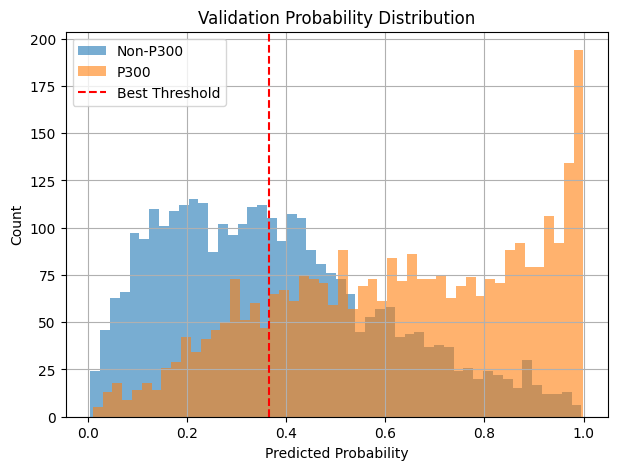

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(probs_val[y_true == 0], bins=50, alpha=0.6, label="Non-P300")
plt.hist(probs_val[y_true == 1], bins=50, alpha=0.6, label="P300")
plt.axvline(best_threshold, color='red', linestyle='--', label='Best Threshold')
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Validation Probability Distribution")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_true,
    probs_val
)

# thresholds has length = len(precision) - 1
precision = precision[:-1]
recall = recall[:-1]

f1 = 2 * precision * recall / (precision + recall + 1e-8)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (VAL): {best_threshold:.4f}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall:    {recall[best_idx]:.4f}")
print(f"F1-score:  {f1[best_idx]:.4f}")

Best Threshold (VAL): 0.3649
Precision: 0.6356
Recall:    0.8149
F1-score:  0.7141


In [35]:
y_test_pred_prob = model.predict(X_test_final)
y_test_pred = (y_test_pred_prob[:, 1] >= best_threshold).astype(int)

197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


              precision    recall  f1-score   support

    Non-P300       0.73      0.59      0.65      3150
        P300       0.66      0.78      0.71      3150

    accuracy                           0.68      6300
   macro avg       0.69      0.68      0.68      6300
weighted avg       0.69      0.68      0.68      6300



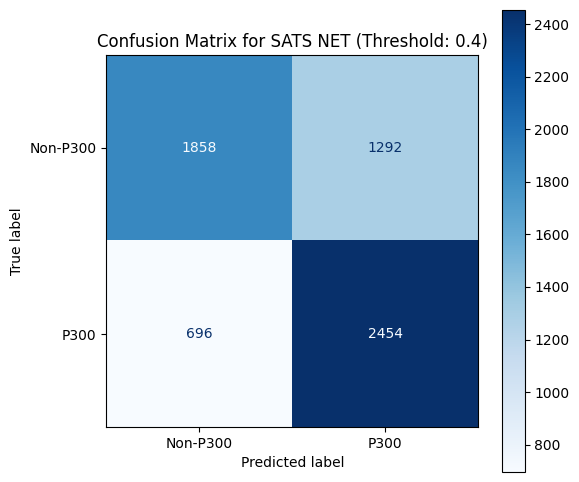

In [36]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_true,
    probs_val
)
f1 = 2 * precision * recall / (precision + recall + 1e-8)
best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]
y_pred = (probs_val >= 0.4).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true, y_pred, target_names=["Non-P300", "P300"]))
plot_confusion_matrix(y_true, y_pred, "SATS NET", labels=['Non-P300', 'P300'], title_suffix=f' (Threshold: {0.4})')

Available metrics in history: ['auc', 'loss', 'precision_nonp300', 'precision_p300', 'recall_nonp300', 'recall_p300', 'val_auc', 'val_loss', 'val_precision_nonp300', 'val_precision_p300', 'val_recall_nonp300', 'val_recall_p300']


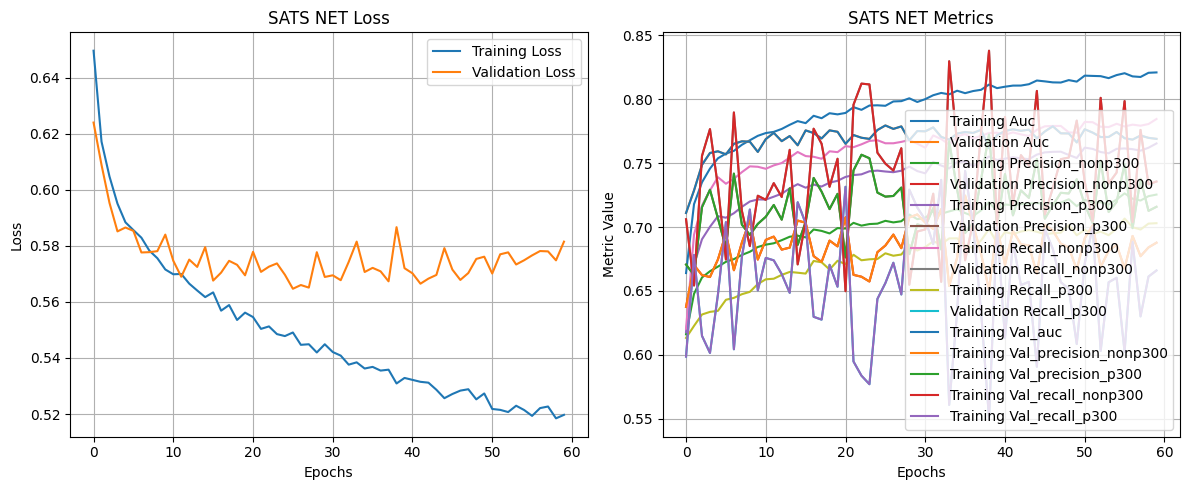

In [37]:
plot_training_history(history, "SATS NET")

In [41]:
all_y_true = []
all_y_pred = []

loso_results = []
from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import gc

unique_subjects = np.unique(subject_ids)

print(f"\nStarting LOSO-CV with {len(unique_subjects)} subjects...\n")

for fold, test_subject in enumerate(unique_subjects, 1):

    print(f"\n==============================")
    print(f"LOSO Fold {fold}/{len(unique_subjects)}")
    print(f"Test Subject: {test_subject}")
    print(f"==============================")

    # -----------------------------
    # SPLIT
    # -----------------------------
    test_mask  = subject_ids == test_subject
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    # -----------------------------
    # DOWNSAMPLING (TRAIN ONLY)
    # -----------------------------
    idx_p300    = np.where(y_train == 1)[0]
    idx_nonp300 = np.where(y_train == 0)[0]

    np.random.shuffle(idx_nonp300)
    idx_nonp300 = idx_nonp300[:len(idx_p300)]

    idx_balanced = np.concatenate([idx_p300, idx_nonp300])
    np.random.shuffle(idx_balanced)

    X_train = X_train[idx_balanced]
    y_train = y_train[idx_balanced]

    X_train = X_train[..., np.newaxis]   # (N, T, C, 1)
    X_test  = X_test[..., np.newaxis]


    # -----------------------------
    # ONE-HOT
    # -----------------------------
    y_train_cat = to_categorical(y_train, 2)

    # -----------------------------
    # BUILD MODEL
    # -----------------------------
    model = build_SATS_Net(X_train.shape[1:],y_train_cat.shape[1])

    # -----------------------------
    # TRAIN
    # -----------------------------
    model.fit(
        X_train,
        y_train_cat,
        epochs=20,
        batch_size=16,
        shuffle=True,
        verbose=0
    )

    # -----------------------------
    # TEST (NO THRESHOLD TUNING)
    # -----------------------------
    probs_test = model.predict(X_test, verbose=0)[:, 1]
    y_pred = (probs_test >= 0.5).astype(int)

    # -----------------------------
    # METRICS
    # -----------------------------
    f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

    print(f"F1 P300     : {f1_p300:.4f}")
    print(f"F1 Non-P300 : {f1_nonp300:.4f}")

    loso_results.append({
        "subject": test_subject,
        "f1_p300": f1_p300,
        "f1_nonp300": f1_nonp300
    })

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    # -----------------------------
    # CLEANUP
    # -----------------------------
    del model
    tf.keras.backend.clear_session()
    gc.collect()


Starting LOSO-CV with 15 subjects...


LOSO Fold 1/15
Test Subject: 1
F1 P300     : 0.2904
F1 Non-P300 : 0.8408

LOSO Fold 2/15
Test Subject: 2
F1 P300     : 0.4740
F1 Non-P300 : 0.9198

LOSO Fold 3/15
Test Subject: 3
F1 P300     : 0.3168
F1 Non-P300 : 0.7940

LOSO Fold 4/15
Test Subject: 4
F1 P300     : 0.3752
F1 Non-P300 : 0.8359

LOSO Fold 5/15
Test Subject: 5
F1 P300     : 0.3722
F1 Non-P300 : 0.7985

LOSO Fold 6/15
Test Subject: 6
F1 P300     : 0.3464
F1 Non-P300 : 0.8424

LOSO Fold 7/15
Test Subject: 7
F1 P300     : 0.4738
F1 Non-P300 : 0.8879

LOSO Fold 8/15
Test Subject: 8
F1 P300     : 0.5585
F1 Non-P300 : 0.9024

LOSO Fold 9/15
Test Subject: 9
F1 P300     : 0.3638
F1 Non-P300 : 0.8436

LOSO Fold 10/15
Test Subject: 10
F1 P300     : 0.3802
F1 Non-P300 : 0.7511

LOSO Fold 11/15
Test Subject: 11
F1 P300     : 0.3616
F1 Non-P300 : 0.7962

LOSO Fold 12/15
Test Subject: 12
F1 P300     : 0.3626
F1 Non-P300 : 0.8434

LOSO Fold 13/15
Test Subject: 13
F1 P300     : 0.3456
F1 Non-P300 

In [42]:
import pandas as pd

df_loso = pd.DataFrame(loso_results)

print("\n========== LOSO SUMMARY ==========")
print(df_loso)

print("\nMean F1 P300     :", df_loso["f1_p300"].mean())
print("Mean F1 Non-P300 :", df_loso["f1_nonp300"].mean())


========== LOSO SUMMARY ==========
    subject   f1_p300  f1_nonp300
0         1  0.290378    0.840776
1         2  0.474004    0.919848
2         3  0.316824    0.794027
3         4  0.375188    0.835917
4         5  0.372221    0.798490
5         6  0.346428    0.842356
6         7  0.473818    0.887902
7         8  0.558541    0.902361
8         9  0.363801    0.843604
9        10  0.380181    0.751095
10       11  0.361624    0.796231
11       12  0.362608    0.843399
12       13  0.345554    0.805697
13       14  0.288180    0.853467
14       15  0.329097    0.755664

Mean F1 P300     : 0.3758963165486569
Mean F1 Non-P300 : 0.8313888898112312



=== LOSO FINAL REPORT ===
              precision    recall  f1-score   support

    Non-P300       0.93      0.75      0.83    147000
        P300       0.26      0.62      0.37     21000

    accuracy                           0.74    168000
   macro avg       0.60      0.69      0.60    168000
weighted avg       0.85      0.74      0.78    168000



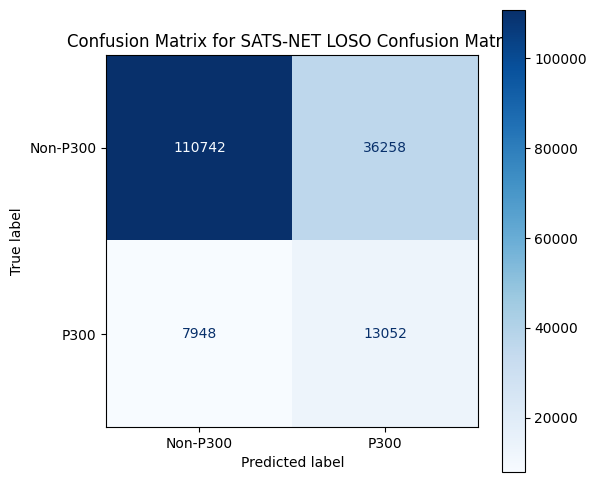

In [43]:
from sklearn.metrics import classification_report

print("\n=== LOSO FINAL REPORT ===")
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    np.array(all_y_true),
    np.array(all_y_pred),
    "SATS-NET LOSO Confusion Matrix"
)

In [44]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
import numpy as np
import gc
import tensorflow as tf

# -----------------------------
# SETUP
# -----------------------------
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

unique_subjects = np.unique(subject_ids)
subject_kfold_results = []

print(f"\nStarting Subject-wise {k}-Fold CV...\n")

# -----------------------------
# SUBJECT LOOP
# -----------------------------
for subject in unique_subjects:

    print(f"\n==============================")
    print(f"Subject {subject} | {k}-Fold CV")
    print(f"==============================")

    mask = subject_ids == subject
    X_sub = X[mask]
    y_sub = y[mask]

    fold_f1_p300 = []
    fold_f1_nonp300 = []

    # -----------------------------
    # K-FOLD LOOP
    # -----------------------------
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):

        print(f"\nSubject {subject} | Fold {fold}")

        X_train, X_test = X_sub[train_idx], X_sub[test_idx]
        y_train, y_test = y_sub[train_idx], y_sub[test_idx]

        # -----------------------------
        # DOWNSAMPLING (TRAIN ONLY)
        # -----------------------------
        idx_p300 = np.where(y_train == 1)[0]
        idx_nonp300 = np.where(y_train == 0)[0]

        np.random.shuffle(idx_nonp300)
        idx_nonp300 = idx_nonp300[:len(idx_p300)]

        idx_balanced = np.concatenate([idx_p300, idx_nonp300])
        np.random.shuffle(idx_balanced)

        X_train = X_train[idx_balanced]
        y_train = y_train[idx_balanced]

        print(f"Train size: {len(y_train)} | Test size: {len(y_test)}")
        print(f"P300 train: {np.sum(y_train==1)} | Non-P300 train: {np.sum(y_train==0)}")

        # -----------------------------
        # SHAPE FIX (ONLY if Conv2D)
        # -----------------------------
        if len(X_train.shape) == 3:
            X_train = X_train[..., np.newaxis]   # (N, T, C, 1)
            X_test  = X_test[..., np.newaxis]

        # -----------------------------
        # ONE-HOT
        # -----------------------------
        y_train_cat = to_categorical(y_train, 2)

        # -----------------------------
        # BUILD MODEL
        # -----------------------------
        model = build_SATS_Net(
            input_shape=X_train.shape[1:],
            num_classes=2
        )

        # -----------------------------
        # TRAIN
        # -----------------------------
        model.fit(
            X_train,
            y_train_cat,
            epochs=20,
            batch_size=16,
            shuffle=True,
            verbose=0
        )

        # -----------------------------
        # TEST
        # -----------------------------
        probs = model.predict(X_test, verbose=0)[:, 1]
        y_pred = (probs >= 0.5).astype(int)

        f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

        print(f"Fold {fold} | F1 P300: {f1_p300:.3f} | F1 Non-P300: {f1_nonp300:.3f}")

        fold_f1_p300.append(f1_p300)
        fold_f1_nonp300.append(f1_nonp300)

        # -----------------------------
        # CLEANUP
        # -----------------------------
        del model
        tf.keras.backend.clear_session()
        gc.collect()
        
        # -----------------------------
        # SUBJECT AVERAGE
        # -----------------------------
        subject_kfold_results.append({
        "subject": subject,
        "f1_p300": np.mean(fold_f1_p300),
        "f1_nonp300": np.mean(fold_f1_nonp300)
        })

    print("\nSubject-wise K-Fold CV complete!")


Starting Subject-wise 5-Fold CV...


Subject 1 | 5-Fold CV

Subject 1 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.365 | F1 Non-P300: 0.824

Subject 1 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.357 | F1 Non-P300: 0.789

Subject 1 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 3 | F1 P300: 0.366 | F1 Non-P300: 0.795

Subject 1 | Fold 4
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 4 | F1 P300: 0.394 | F1 Non-P300: 0.823

Subject 1 | Fold 5
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 5 | F1 P300: 0.405 | F1 Non-P300: 0.829

Subject-wise K-Fold CV complete!

Subject 2 | 5-Fold CV

Subject 2 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.613 | F1 Non-P300: 0.918

Subject 2 | Fold 2
Train size: 2240 | Test

In [45]:
import pandas as pd
df_subject_kfold = pd.DataFrame(subject_kfold_results)

print(df_subject_kfold)
print("\nMean Subject-wise F1 P300     :", df_subject_kfold.f1_p300.mean())
print("Mean Subject-wise F1 Non-P300 :", df_subject_kfold.f1_nonp300.mean())

    subject   f1_p300  f1_nonp300
0         1  0.364573    0.824166
1         1  0.360567    0.806750
2         1  0.362366    0.802965
3         1  0.370297    0.807851
4         1  0.377275    0.812008
..      ...       ...         ...
70       15  0.525180    0.891388
71       15  0.526851    0.889770
72       15  0.527960    0.890108
73       15  0.529347    0.893717
74       15  0.531969    0.895413

[75 rows x 3 columns]

Mean Subject-wise F1 P300     : 0.480911761762131
Mean Subject-wise F1 Non-P300 : 0.8667004186947206
